In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('heart.csv')
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


# EDA

In [3]:
df.shape

(918, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

<Axes: xlabel='Sex'>

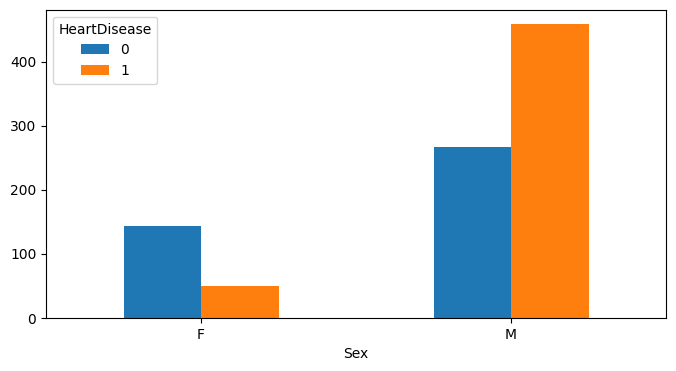

In [9]:
pd.crosstab(df.Sex, df.HeartDisease).plot(kind='bar', figsize=(8,4), rot=0)

In [10]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [11]:
numeric_col = df.select_dtypes(include = 'number').columns
numeric_col

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease'],
      dtype='object')

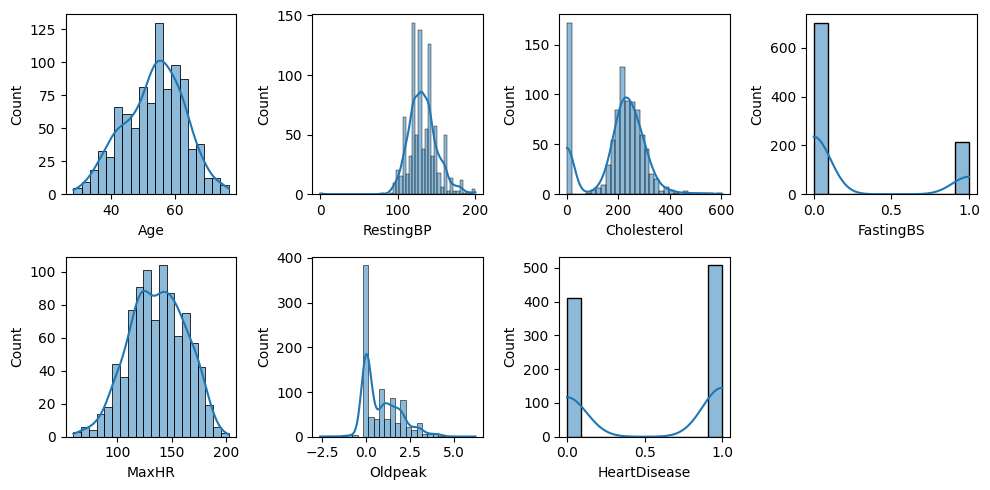

In [12]:
plt.figure(figsize=(10,5))
i=1
for col in (numeric_col):
    plt.subplot(2,4,i)
    sns.histplot(df[col], kde=True)
    i += 1
    plt.tight_layout()

### Note: RestingBP and Cholesterol they both can't be zero. Even if the person is dead still they the value can't be zero.


In [13]:
df.Cholesterol.value_counts()

Cholesterol
0      172
254     11
223     10
220     10
230      9
      ... 
392      1
316      1
153      1
466      1
131      1
Name: count, Length: 222, dtype: int64

In [14]:
cholesterol_mean = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].mean()
cholesterol_mean

np.float64(244.6353887399464)

In [15]:
df['Cholesterol'].replace(0, cholesterol_mean, inplace=True)
df.Cholesterol = df.Cholesterol.round(2)
df.Cholesterol.value_counts()

Cholesterol
244.64    172
254.00     11
223.00     10
220.00     10
230.00      9
         ... 
392.00      1
316.00      1
153.00      1
466.00      1
131.00      1
Name: count, Length: 222, dtype: int64

In [16]:
df.RestingBP.unique()


array([140, 160, 130, 138, 150, 120, 110, 136, 115, 100, 124, 113, 125,
       145, 112, 132, 118, 170, 142, 190, 135, 180, 108, 155, 128, 106,
        92, 200, 122,  98, 105, 133,  95,  80, 137, 185, 165, 126, 152,
       116,   0, 144, 154, 134, 104, 139, 131, 141, 178, 146, 158, 123,
       102,  96, 143, 172, 156, 114, 127, 101, 174,  94, 148, 117, 192,
       129, 164])

In [17]:
(df.RestingBP == 0).sum()

np.int64(1)

In [18]:
RestingBP_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()
RestingBP_mean

np.float64(132.54089422028352)

In [19]:
df['RestingBP'].replace(0, RestingBP_mean, inplace=True)
df.RestingBP = df.RestingBP.round(2)
df.RestingBP.value_counts()

RestingBP
120.0    132
130.0    118
140.0    107
110.0     58
150.0     55
        ... 
185.0      1
98.0       1
92.0       1
113.0      1
164.0      1
Name: count, Length: 67, dtype: int64

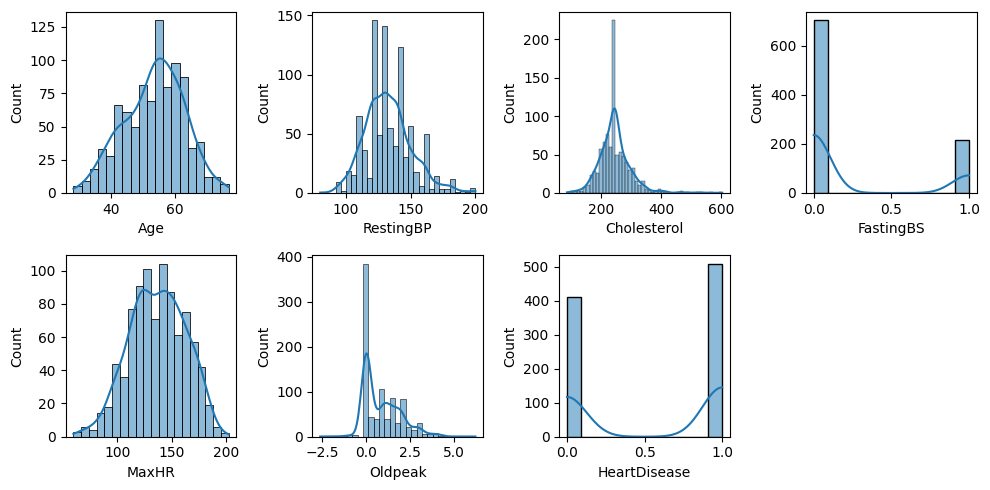

In [20]:
plt.figure(figsize=(10,5))
i=1
for col in (numeric_col):
    plt.subplot(2,4,i)
    sns.histplot(df[col], kde=True)
    i += 1
    plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

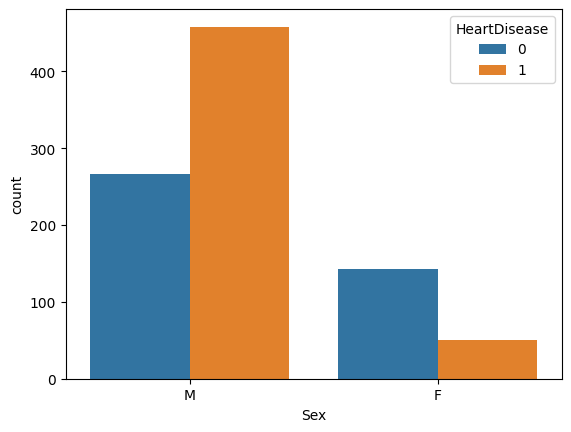

In [21]:
sns.countplot(x = df['Sex'], hue = df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

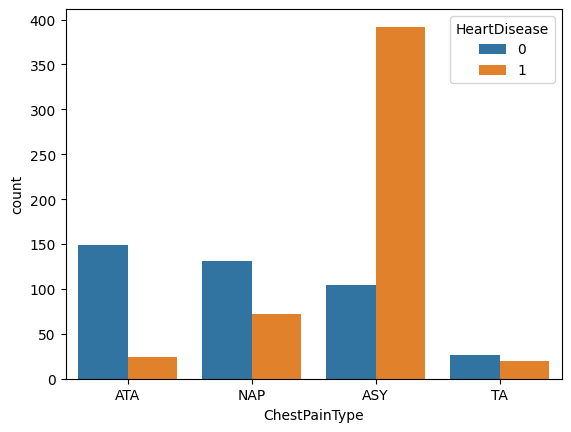

In [22]:
sns.countplot(x = df['ChestPainType'], hue = df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

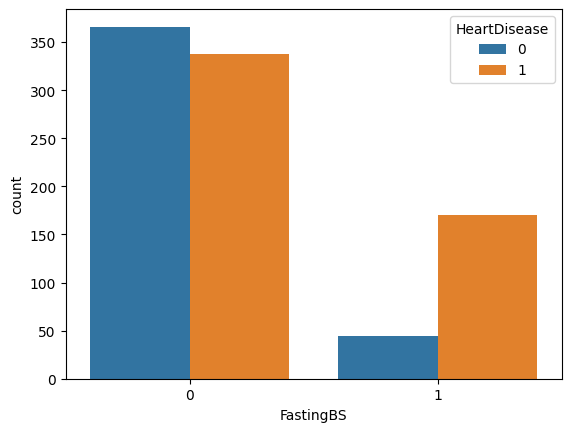

In [23]:
sns.countplot(x = df['FastingBS'], hue = df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

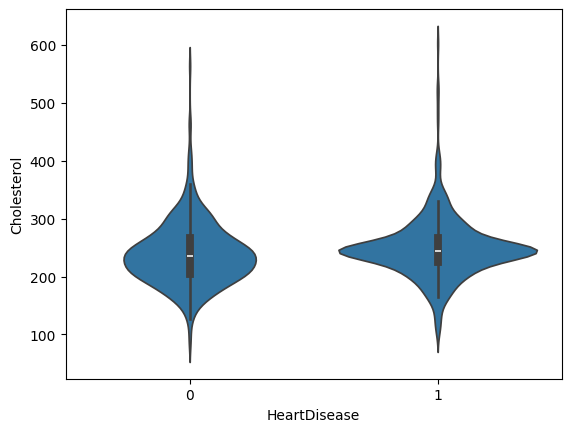

In [24]:
sns.violinplot(x = df['HeartDisease'], y = df['Cholesterol'])

<Axes: xlabel='HeartDisease', ylabel='Age'>

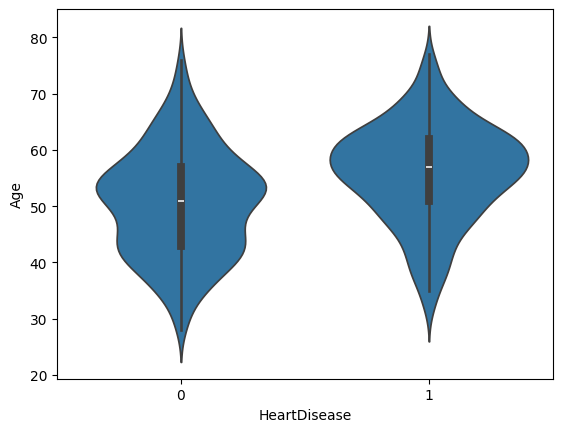

In [25]:
sns.violinplot(x = df['HeartDisease'], y = df['Age'])

<Axes: >

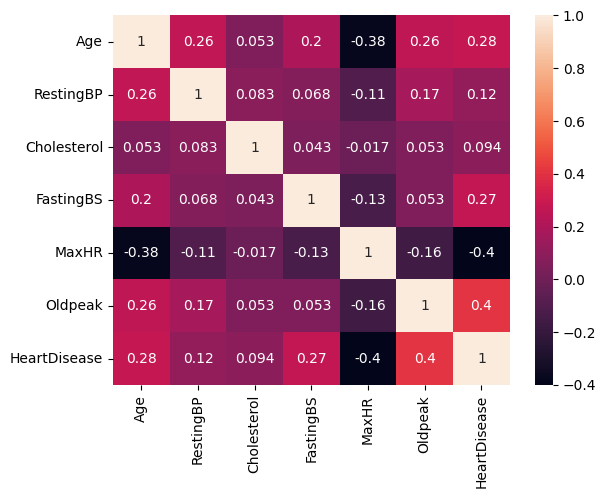

In [26]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

# Data cleaning and preprocessing

In [27]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,True,False,False,True,True,False,False,True,False
914,68,144.0,193.0,1,141,3.4,1,True,False,False,False,True,False,False,True,False
915,57,130.0,131.0,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130.0,236.0,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [28]:
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
df_encoded

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160.0,180.0,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130.0,283.0,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138.0,214.0,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150.0,195.0,0,122,0.0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110.0,264.0,0,132,1.2,1,1,0,0,1,1,0,0,1,0
914,68,144.0,193.0,1,141,3.4,1,1,0,0,0,1,0,0,1,0
915,57,130.0,131.0,0,115,1.2,1,1,0,0,0,1,0,1,1,0
916,57,130.0,236.0,0,174,0.0,1,0,1,0,0,0,0,0,1,0


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# train_test_split

In [31]:
X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# LogisticRegression

In [33]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred_logis = model.predict(X_test_scaled)

In [34]:
acc_lr = accuracy_score(y_test, y_pred_logis)
print("Accuracy:", acc_lr)

Accuracy: 0.8641304347826086


In [35]:
confusion = confusion_matrix(y_test, y_pred_logis)
print("Confusion Matrix:\n", confusion)

Confusion Matrix:
 [[68  9]
 [16 91]]


In [36]:
classification_report = classification_report(y_test, y_pred_logis)
print("Classification Report:\n", classification_report)

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.88      0.84        77
           1       0.91      0.85      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184



In [37]:
roc_auc_score = roc_auc_score(y_test, y_pred_logis)
print("ROC AUC Score:", roc_auc_score)

ROC AUC Score: 0.8667920864182546


# GaussianNB

In [38]:
model = GaussianNB()
model.fit(X_train_scaled, y_train)
y_pred_NB = model.predict(X_test_scaled)

In [39]:
acc_nb = accuracy_score(y_test, y_pred_NB)
print("Accuracy:", acc_nb)

Accuracy: 0.8478260869565217


In [40]:
confusion = confusion_matrix(y_test, y_pred_NB)
print("Confusion Matrix:\n", confusion)

Confusion Matrix:
 [[69  8]
 [20 87]]


In [41]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_NB))

              precision    recall  f1-score   support

           0       0.78      0.90      0.83        77
           1       0.92      0.81      0.86       107

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.86      0.85      0.85       184



# DecisionTreeClassifier

In [42]:
model = DecisionTreeClassifier()
model.fit(X_train_scaled, y_train)
y_pred_tree = model.predict(X_test_scaled)

In [43]:
acc_dt = accuracy_score(y_test, y_pred_tree)
print("Accuracy:", acc_dt)

Accuracy: 0.7880434782608695


In [44]:
confusion = confusion_matrix(y_test, y_pred_tree)
print("Confusion Matrix:\n", confusion)

Confusion Matrix:
 [[61 16]
 [23 84]]


In [45]:
from sklearn.metrics import classification_report
classification_report = classification_report(y_test, y_pred_tree)
print("Classification Report:\n", classification_report)

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.79      0.76        77
           1       0.84      0.79      0.81       107

    accuracy                           0.79       184
   macro avg       0.78      0.79      0.78       184
weighted avg       0.79      0.79      0.79       184



# SVC

In [46]:
model_svc = SVC(kernel='linear', random_state=42, probability=True)
model_svc.fit(X_train_scaled, y_train)
y_pred_svc = model_svc.predict(X_test_scaled)

In [47]:
acc_svc = accuracy_score(y_test, y_pred_svc)
print("Accuracy:", acc_svc)

Accuracy: 0.8532608695652174


In [48]:
confusion = confusion_matrix(y_test, y_pred_svc)
print("Confusion Matrix:\n", confusion)

Confusion Matrix:
 [[67 10]
 [17 90]]


In [49]:
from sklearn.metrics import classification_report
classification_report = classification_report(y_test, y_pred_svc)
print("Classification Report:\n", classification_report)

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.87      0.83        77
           1       0.90      0.84      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



# KNeighborsClassifier

In [50]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)

In [51]:
acc_knn = accuracy_score(y_test, y_pred_knn)
print("Accuracy:", acc_knn)

Accuracy: 0.8532608695652174


In [52]:
confusion = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:\n", confusion)

Confusion Matrix:
 [[66 11]
 [16 91]]


In [53]:
from sklearn.metrics import classification_report
classification_report = classification_report(y_test, y_pred_knn)
print("Classification Report:\n", classification_report)

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.86      0.83        77
           1       0.89      0.85      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.86      0.85      0.85       184



In [54]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'SVC', 'Gaussian NB', 'KNN'],
    'Accuracy': [acc_lr, acc_dt, acc_svc, acc_nb, acc_knn]
})

comparison.sort_values( by='Accuracy', ascending=False, inplace=True)
comparison

,Model,Accuracy
0,Logistic Regression,0.864130
2,SVC,0.853261
4,KNN,0.853261
3,Gaussian NB,0.847826
1,Decision Tree,0.788043


# Feature extraction and engineering

##### One-Hot Encoding
##### Label Encoding
##### Binning (pd.cut)
##### Log Transform (np.log1p)
##### Creating interaction features
##### StandardScaler

In [55]:
scaler

StandardScaler()

# Frontend

In [56]:
import joblib
joblib.dump(model_svc, 'SVC_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(X.columns.tolist(), 'columns.joblib')

['columns.joblib']